Estratégias de arbitragem para diferentes tipos de ativos

In [278]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import backtrader as bt
import yfinance as yf
import math

from statsmodels.tsa.stattools import coint          # Engle–Granger
from statsmodels.tsa.vector_ar.vecm import (          # Johansen
    coint_johansen,
    select_order
)

CDI = [0.0276, 0.0442, 0.1239, 0.1304, 0.1088, 0.1331] #dados anuais de 2020-2025
cdi_aa = (((1 + CDI[0])*(1+CDI[1])*(1+CDI[2])*(1+CDI[3])*(1+CDI[4])*(1+CDI[5])) ** (1/6)) - 1

cdi_d = ((1 + cdi_aa) ** (1/252)) - 1
print(cdi_aa, cdi_d)

commodities_t = ["GC=F", "SI=F", 'CL=F', "BZ=F", "NG=F", "TIO=F", "HG=F"]

forex_t = ["AUDBRL=X", "BRL=X", "CADBRL=X"]

acoes_t = ["PETR4.SA", "NG=F", "PETR3.SA", "CL=F", "GGBR4.SA", "SI=F", "VALE3.SA", "TIO=F", "AUDBRL=X", "CADBRL=X", "GC=F", "BZ=F", "CSAN3.SA", "BRL=X", "SB=F", "HG=F", "CVX"]


date_from = "2020-07-31"
date_to = "2025-07-31"

commodities = yf.download(commodities_t, start=date_from, end=date_to, interval='1d')["Close"]
forex = yf.download(forex_t, start=date_from, end=date_to, interval='1d')["Close"]
ativos = yf.download(acoes_t, start=date_from, end=date_to, interval='1d')["Close"]

ativos = ativos.dropna(how="any")  # drop dates where any ticker is missing

#fx = forex["BRL=X"].ffill()  # forward-fill, in case of missing days
#Convertendo preço das commodities para real
#converted = commodities.mul(fx, axis=0)
#converted.columns = [c + "_BRL" for c in commodities_t]
#ativos = ativos.join(converted)

petr_clf = yf.download(["BHP", "TIO=F", "CVX", "CL=F", "HRL", "LET=F"], start=date_from, end=date_to, interval='1d')

#close = petr_clf["Close"].copy()

# série do BRL (fechamento)
#brl_close = petr_clf["Close"]["BRL=X"]
#futuros = ["CL=F", "SI=F", "TIO=F", "GC=F", "BZ=F", "SB=F", "HG=F", "NG=F"]

#for t in futuros:
#    petr_clf[("Close", t + "_BRL")] = petr_clf["Close"][t] * brl_close


#petroleo = yf.download(["PETR4.SA", "XOM", "CVX", "PRIO3.SA", "SLB", "CL=F"], start="2015-01-01", end="2019-12-31", interval='1d')["Close"]
#mine = yf.download(["VALE3.SA", "RIO", "BHP", "TIO=F"], start="2015-01-01", end="2019-12-31", interval='1d')["Close"]
#aerea = yf.download(["AAL", "AZUL4.SA", "DAL", "BZ=F"], start="2015-01-01", end="2019-12-31", interval='1d')["Close"]
#agric = yf.download(["BEEF3.SA", "HRL", "LET=F"], start="2015-01-01", end="2019-12-31", interval='1d')["Close"]

/tmp/ipykernel_20754/2630307894.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  commodities = yf.download(commodities_t, start=date_from, end=date_to, interval='1d')["Close"]
[*********************100%***********************]  7 of 7 completed
/tmp/ipykernel_20754/2630307894.py:33: FutureWarning: YF.download() has changed argument auto_adjust default to True
  forex = yf.download(forex_t, start=date_from, end=date_to, interval='1d')["Close"]
[*********************100%***********************]  3 of 3 completed

0.09382583539676292 0.0003559422669683343



/tmp/ipykernel_20754/2630307894.py:34: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ativos = yf.download(acoes_t, start=date_from, end=date_to, interval='1d')["Close"]
[*********************100%***********************]  17 of 17 completed
/tmp/ipykernel_20754/2630307894.py:44: FutureWarning: YF.download() has changed argument auto_adjust default to True
  petr_clf = yf.download(["BHP", "TIO=F", "CVX", "CL=F", "HRL", "LET=F"], start=date_from, end=date_to, interval='1d')
[*********************100%***********************]  6 of 6 completed


In [263]:
def engle_granger_dict(prices):
    cols = prices.columns
    pvals = {}  # dicionário: chave = (a, b), valor = pvalue

    for i, a in enumerate(cols):
        for j, b in enumerate(cols):
            # pula diagonal e triângulo inferior para não repetir pares
            if i >= j:
                continue

            score, pvalue, crit_values = coint(prices[a], prices[b], maxlag=1)
            pvals[(a, b)] = pvalue

    return pvals
    
pvals_petr = engle_granger_dict(petroleo.dropna(how="any"))
pvals_mine = engle_granger_dict(mine.dropna(how="any"))
pvals_ar = engle_granger_dict(agric.dropna(how="any"))
pvals_agr = engle_granger_dict(agric.dropna(how="any"))

print(pvals_petr)
print(pvals_mine)
print(pvals_ar)

{('CL=F', 'CVX'): 0.19096620773314082, ('CL=F', 'PETR4.SA'): 0.3053122519645083, ('CL=F', 'PRIO3.SA'): 0.46435763751534587, ('CL=F', 'SLB'): 0.4079099242085502, ('CL=F', 'XOM'): 0.633285574421715, ('CVX', 'PETR4.SA'): 0.19051993302642972, ('CVX', 'PRIO3.SA'): 0.8269748933041773, ('CVX', 'SLB'): 0.28027840470157567, ('CVX', 'XOM'): 0.9445783559316291, ('PETR4.SA', 'PRIO3.SA'): 0.7736092577139748, ('PETR4.SA', 'SLB'): 0.25456176746215425, ('PETR4.SA', 'XOM'): 0.9820131979305481, ('PRIO3.SA', 'SLB'): 0.9832945161429661, ('PRIO3.SA', 'XOM'): 1.0, ('SLB', 'XOM'): 0.9373718969569191}
{('BHP', 'RIO'): 0.14723141132455875, ('BHP', 'TIO=F'): 0.3358157095708012, ('BHP', 'VALE3.SA'): 0.2943845662624983, ('RIO', 'TIO=F'): 0.39819715771703523, ('RIO', 'VALE3.SA'): 0.3621985521209412, ('TIO=F', 'VALE3.SA'): 0.39064588743046413}
{('BEEF3.SA', 'HRL'): 0.8395427287877961, ('BEEF3.SA', 'LET=F'): 0.8429335195710685, ('HRL', 'LET=F'): 0.6487925234391588}


In [279]:
import backtrader as bt
import numpy as np
from collections import deque


class CointegratedArbitrage(bt.Strategy):
    params = dict(
        lookback=30,      # window for regression & z-score
        entry_z=1.5,       # entry threshold
        exit_z=1.5,        # exit threshold
        max_alloc=0.3,     # max fraction of equity per trade
        min_spread_std=1e-6,  # guard against zero std
    )

    def __init__(self):
        self.stock = self.datas[0]
        self.commod = self.datas[1]

        self.spread_hist = deque(maxlen=self.p.lookback)
        self.alpha = None
        self.beta = None

    def log(self, txt):
        dt = self.datas[0].datetime.date(0)
        print(f'{dt.isoformat()} - {txt}')

    def has_open_spread(self):
        return (self.getposition(self.stock).size != 0 or
                self.getposition(self.commod).size != 0)

    def compute_hedge_ratio(self):
        lb = self.p.lookback

        # 1) Need enough bars
        if len(self.stock) < lb or len(self.commod) < lb:
            return self.alpha, self.beta  # or (None, None) the first times

        xs, ys = [], []
        for i in range(lb, 0, -1):
            px = float(self.commod.close[-i])
            py = float(self.stock.close[-i])

            # skip bars where either series is bad
            if not np.isfinite(px) or not np.isfinite(py):
                continue
            if px <= 0 or py <= 0:
                continue

            xs.append(math.log(px))
            ys.append(math.log(py))

        # 2) Need at least 2 valid points for degree-1 polyfit
        if len(xs) <= 2:
            return self.alpha, self.beta

        x = np.array(xs, dtype=float)
        y = np.array(ys, dtype=float)

        # extra safety: filter non-finite again
        mask = np.isfinite(x) & np.isfinite(y)
        x = x[mask]
        y = y[mask]
        if len(x) <= 2:
            return self.alpha, self.beta

        # 3) Run regression with error handling
        try:
            beta, alpha = np.polyfit(x, y, 1)
        except np.linalg.LinAlgError:
            # keep previous hedge ratio if regression is unstable
            return self.alpha, self.beta

        return alpha, beta

        
    def next(self):
        # 1) Need enough data
        if len(self.stock) < self.p.lookback or len(self.commod) < self.p.lookback:
            return

        # 2) Compute/update hedge ratio each bar (you might do this less often in production)
        self.alpha, self.beta = self.compute_hedge_ratio()
        if self.alpha is None:
            return

        # 3) Compute current spread
        log_stock = np.log(self.stock.close[0])
        log_commod = np.log(self.commod.close[0])
        spread = log_stock - (self.alpha + self.beta * log_commod)

        # 4) Update spread history and compute z-score
        self.spread_hist.append(spread)
        if len(self.spread_hist) < self.p.lookback:
            return

        mu = np.mean(self.spread_hist)
        std = np.std(self.spread_hist)

        if std < self.p.min_spread_std:
            return  # no variation -> don't tradecommodity barril de petroleo ticker yfinance

        z = (spread - mu) / std

        # 5) Get current positions
        pos_stock = self.getposition(self.stock).size
        pos_commod = self.getposition(self.commod).size

        # 6) Entry logic: no open spread
        if pos_stock == 0 and pos_commod == 0:
            if z > self.p.entry_z:
                # Spread high: stock expensive vs commod
                self.log(f'Enter SHORT stock / LONG commod | z={z:.2f}')
                self.open_spread(short_stock=True)
            elif z < -self.p.entry_z:
                # Spread low: stock cheap vs commod
                self.log(f'Enter LONG stock / SHORT commod | z={z:.2f}')
                self.open_spread(short_stock=False)

        # 7) Exit logic: spread has reverted
        else:
            if abs(z) <= self.p.exit_z:
                self.log(f'Exit spread | z={z:.2f}')
                self.close(self.stock)
                self.close(self.commod)

    def open_spread(self, short_stock: bool):
        """
        Open a market-neutral(ish) spread position:
        - 1 leg in stock
        - hedge leg in commod based on beta, scaled by notionals.
        """
        value = self.broker.getvalue()

        stock_price = self.stock.close[0]
        commod_price = self.commod.close[0]

        if stock_price <= 0 or commod_price <= 0 or self.beta is None:
            return

        # Capital allocated to this spread
        alloc = value * self.p.max_alloc

        # We'll allocate half of 'alloc' to each side notionally
        stock_notional = alloc / 2.0
        commod_notional = alloc / 2.0

        # Number of shares/contracts (integer)
        stock_size = int(stock_notional / stock_price)
        # Hedge ratio in *value*-space: target about beta exposure
        # Here we approximate needed commod units to match beta * stock exposure
        commod_size = int((stock_size * stock_price * self.beta) / commod_price)

        # avoid tiny trades
        if stock_size <= 0 or commod_size == 0:
            return

        if short_stock:
            # Short stock, Long commod
            self.sell(data=self.stock, size=stock_size)
            self.buy(data=self.commod, size=abs(commod_size))
        else:
            # Long stock, Short commod
            self.buy(data=self.stock, size=stock_size)
            # commod_size can be negative if beta < 0
            self.sell(data=self.commod, size=abs(commod_size))

        ano = self.data.datetime.date(0).year
        index = ano - 2020
        cdi_a = (1 + CDI[index])
        cdi_d = ((1 + cdi_a) ** (1/252)) - 1
        daily_carry = cdi_d
        self.broker.add_cash(self.broker.get_cash() * daily_carry)        


In [284]:
# Criando uma conta que rentabiliza CDI diariamente:
class CarryBroker(bt.brokers.BackBroker):

    def __init__(self):
        super().__init__()

    def next(self):
        daily_carry = cdi_d
        self.cash += self.cash * daily_carry        
        super().next()

petr_close = petr_clf["Close"]

def simulate(ticker1, ticker2):
    cerebro = bt.Cerebro()
    cerebro.broker = CarryBroker()

    # transforma em DataFrame com uma coluna chamada 'close'
    df1 = petr_close[[ticker1]].copy()
    df1.columns = ['close']

    df2 = petr_close[[ticker2]].copy()
    df2.columns = ['close']

    petr = bt.feeds.PandasData(
        dataname=df1,
        datetime=None,   # usa o índice (Date) como datetime
        open=None,
        high=None,
        low=None,
        close='close',   # nome da coluna
        volume=None,
        openinterest=None,
    )

    barr = bt.feeds.PandasData(
        dataname=df2,
        datetime=None,
        open=None,
        high=None,
        low=None,
        close='close',
        volume=None,
        openinterest=None,
    )

    cerebro.adddata(petr)
    cerebro.adddata(barr)

    
    cerebro.addstrategy(CointegratedArbitrage,
                        lookback=30,
                        entry_z=2,
                        exit_z=0.5,
                        max_alloc=0.3)

    CUSTO_EMOLUMENTOS = (0.005 + 0.0275) / 100  # taxea de 0.005% + 0.0275% (emolumentos)

    cerebro.broker = CarryBroker()
    
    # Ajustando parâmetros de carteira
    cerebro.broker.setcash(1_000_000)
    cerebro.broker.setcommission(commission=CUSTO_EMOLUMENTOS)
    cerebro.broker.set_coc(True)  # cheat on close - para comprar no mesmo dia
    
    # Performance & Risk Metrics
    cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')
    cerebro.addanalyzer(bt.analyzers.TimeReturn, timeframe=bt.TimeFrame.NoTimeFrame, _name='timereturn')
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe', riskfreerate=cdi_aa/100, factor=252)
    cerebro.addanalyzer(bt.analyzers.SQN, _name='sqn')  # System Quality Number
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')
    cerebro.addanalyzer(bt.analyzers.Calmar, _name='calmar')
    cerebro.addanalyzer(bt.analyzers.VWR, _name='vwr')  # Variability-Weighted Return
    
    # Trade
    cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trade_analyzer')
    cerebro.addanalyzer(bt.analyzers.Transactions, _name='transactions')
    cerebro.addanalyzer(bt.analyzers.PositionsValue, _name='positions')
    
    # Drawdown
    cerebro.addanalyzer(bt.analyzers.TimeDrawDown, _name='timedrawdown')
    cerebro.addanalyzer(bt.analyzers.GrossLeverage, _name='leverage')
    
    # Portfolio Analysis
    cerebro.addanalyzer(bt.analyzers.PyFolio, _name='pyfolio')
    
    # Run the strategy
    results = cerebro.run()
    strat = results[0]
    
    # Extract and display all performance metrics
    print("=" * 60)
    print("PERFORMANCE METRICS SUMMARY")
    print("=" * 60)
    
    # Basic Returns
    returns_analyzer = strat.analyzers.returns.get_analysis()
    print(f"Total Return: {returns_analyzer['rtot']:.2%}")
    print(f"Average Return: {returns_analyzer['ravg']:.4%}")
    print(f"Compound Annual Growth Rate: {returns_analyzer['rnorm100']:.2%}")
    
    # Sharpe Ratio
    sharpe = strat.analyzers.sharpe.get_analysis()
    print(f"Sharpe Ratio: {sharpe.get('sharperatio', 'N/A'):.4f}" if sharpe.get('sharperatio') else "Sharpe Ratio: N/A")
    
    # System Quality Number
    sqn = strat.analyzers.sqn.get_analysis()
    print(f"System Quality Number (SQN): {sqn.get('sqn', 'N/A'):.4f}" if sqn.get('sqn') else "SQN: N/A")
    
    # DrawDown Analysis
    dd = strat.analyzers.drawdown.get_analysis()
    print(f"Max Drawdown: {dd.max.drawdown:.2%}")
    print(f"Max Drawdown Duration: {dd.max.len} periods")
    print(f"Max Drawdown Money: ${dd.max.moneydown:,.2f}")
    
    # Calmar Ratio (Annual Return / Max Drawdown)
    calmar = strat.analyzers.calmar.get_analysis()
    print(f"Calmar Ratio: {calmar.get('calmar', 'N/A'):.4f}" if calmar.get('calmar') else "Calmar Ratio: N/A")
    
    # VWR - Variability-Weighted Return
    vwr = strat.analyzers.vwr.get_analysis()
    print(f"VWR: {vwr.get('vwr', 'N/A'):.4f}" if vwr.get('vwr') else "VWR: N/A")
    
    print("\n" + "=" * 60)
    print("TRADE ANALYSIS")
    print("=" * 60)
    
    # Trade Analysis
    trade_analysis = strat.analyzers.trade_analyzer.get_analysis()
    total_trades = trade_analysis.total.get('total', 0)
    print(f"Total Trades: {total_trades}")
    
    if total_trades > 0:
        print(f"Total Open Trades: {trade_analysis.total.get('open', 0)}")
        print(f"Total Closed Trades: {trade_analysis.total.get('closed', 0)}")
        
        print(f"\nWinning Trades: {trade_analysis.won.get('total', 0)}")
        print(f"Losing Trades: {trade_analysis.lost.get('total', 0)}")
        print(f"Win Rate: {(trade_analysis.won.get('total', 0) / total_trades) * 100:.1f}%")
        
        if trade_analysis.won.get('total', 0) > 0:
            print(f"Average Win: ${trade_analysis.won.pnl.get('average', 0):,.2f}")
            print(f"Max Win: ${trade_analysis.won.pnl.get('max', 0):,.2f}")
        
        if trade_analysis.lost.get('total', 0) > 0:
            print(f"Average Loss: ${trade_analysis.lost.pnl.get('average', 0):,.2f}")
            print(f"Max Loss: ${trade_analysis.lost.pnl.get('max', 0):,.2f}")
        
        print(f"Average Trade: ${trade_analysis.pnl.get('net', {}).get('average', 0):,.2f}")
        print(f"Average Trade Length: {trade_analysis.len.get('average', 0):.1f} periods")
        
        # Profit Factor
        gross_profit = trade_analysis.won.pnl.get('total', 0)
        gross_loss = abs(trade_analysis.lost.pnl.get('total', 0))
        if gross_loss > 0:
            profit_factor = gross_profit / gross_loss
            print(f"Profit Factor: {profit_factor:.2f}")
    
    print("\n" + "=" * 60)
    print("PORTFOLIO VALUE")
    print("=" * 60)
    print(f"Starting Portfolio Value: $1,000,000.00")
    print(f"Final Portfolio Value: ${cerebro.broker.getvalue():,.2f}")
    print(f"Total P&L: ${cerebro.broker.getvalue() - 1_000_000:,.2f}")
    
    # Pyfolio
    pyfolio_analyzer = strat.analyzers.pyfolio
    returns, positions, transactions, gross_lev = pyfolio_analyzer.get_pf_items()
    print(f"\nReturns Series Length: {len(returns)}")
    print(f"Positions Tracked: {len(positions.columns) if hasattr(positions, 'columns') else 0}")
    print(f"Transactions Recorded: {len(transactions)}")

    # É possível realizar uma análise mais profunda com o pyfolio, mas precisa de uma biblioteca auxiliar

    figs = cerebro.plot(style='candlestick', volume=False, iplot=False, numfigs=1, figsize=(20, 12), dpi=120)
    plt.savefig(f"{ticker1}_{ticker2}_trades.png")
    plt.show()
    
    equity_strategy = (1 + returns).cumprod() * 1_000_000  # série de patrimônio

    cdi_curve = (1 + cdi_d) ** np.arange(len(returns)) * 1_000_000
    cdi_curve = pd.Series(cdi_curve, index=returns.index)

    plt.figure(figsize=(14, 6))
    plt.plot(equity_strategy.index, equity_strategy.values, label='Estratégia', linewidth=2)
    plt.plot(cdi_curve.index, cdi_curve.values, label='CDI (mesmo capital inicial)', linestyle='--')
    plt.title('Patrimônio: Estratégia vs CDI')
    plt.xlabel('Data')
    plt.ylabel('Valor do Portfólio (R$)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{ticker1}_{ticker2}_vs_CDI.png")
    plt.show()

2020-10-28 - Enter LONG stock / SHORT commod | z=-2.12
2020-11-02 - Exit spread | z=0.43
2020-11-03 - Enter SHORT stock / LONG commod | z=2.55
2020-11-19 - Exit spread | z=0.09
2020-11-24 - Enter SHORT stock / LONG commod | z=2.15
2020-11-30 - Exit spread | z=-0.33
2020-12-01 - Enter LONG stock / SHORT commod | z=-2.27
2020-12-15 - Exit spread | z=-0.45
2021-01-29 - Enter LONG stock / SHORT commod | z=-2.53
2021-02-04 - Exit spread | z=0.18
2021-02-16 - Enter SHORT stock / LONG commod | z=2.43
2021-02-26 - Exit spread | z=0.45
2021-03-16 - Enter LONG stock / SHORT commod | z=-2.13
2021-04-01 - Exit spread | z=-0.46
2021-04-26 - Enter SHORT stock / LONG commod | z=2.15
2021-04-30 - Exit spread | z=-0.04
2021-05-19 - Enter LONG stock / SHORT commod | z=-2.08
2021-05-27 - Exit spread | z=-0.12
2021-06-17 - Enter LONG stock / SHORT commod | z=-2.29
2021-06-23 - Exit spread | z=-0.40
2021-07-09 - Enter SHORT stock / LONG commod | z=2.25
2021-07-19 - Exit spread | z=-0.27
2021-08-02 - Enter 

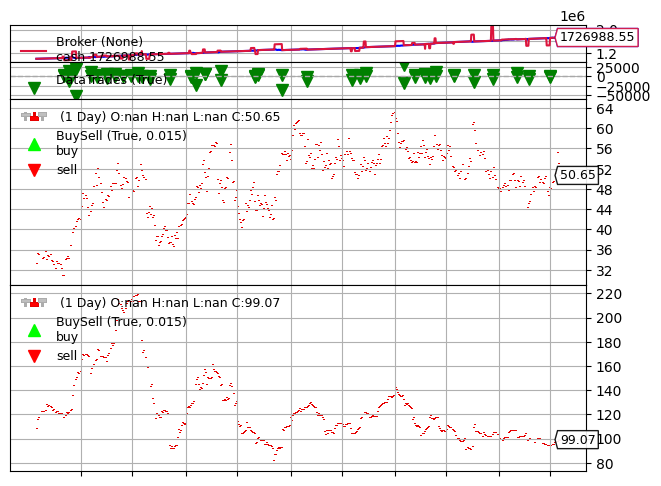

<Figure size 640x480 with 0 Axes>

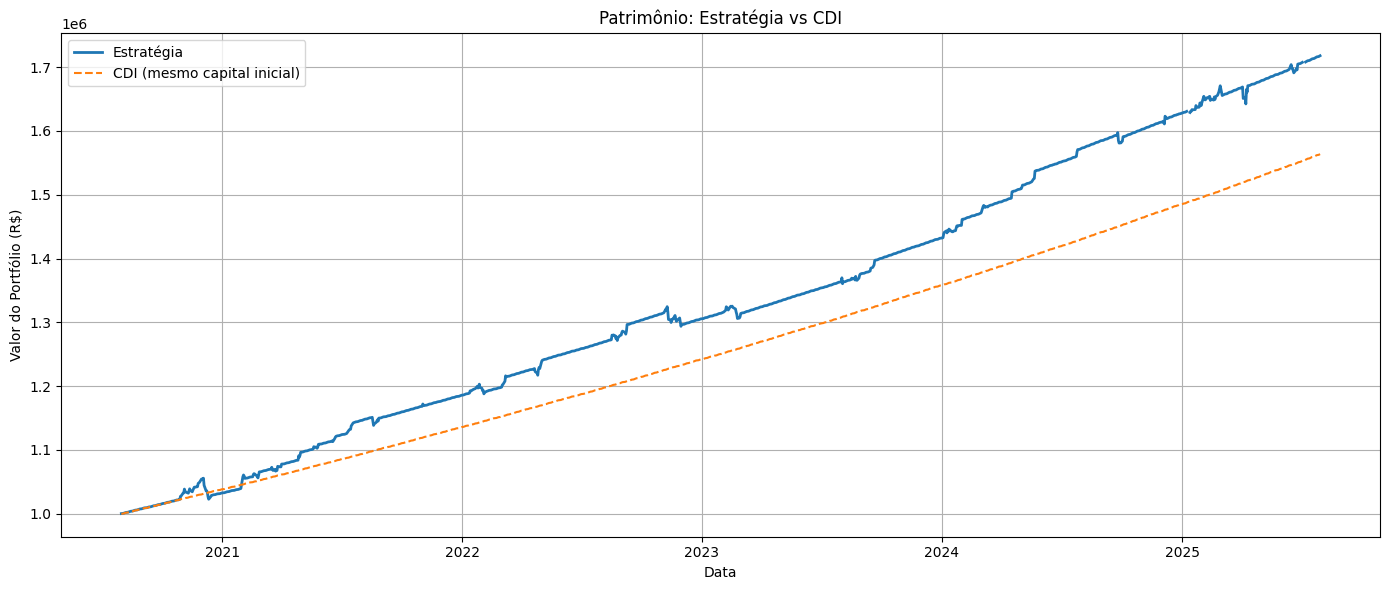

2020-11-02 - Enter SHORT stock / LONG commod | z=2.16
2020-12-30 - Exit spread | z=-0.37
2021-01-07 - Enter SHORT stock / LONG commod | z=2.21
2021-01-21 - Exit spread | z=0.29
2021-03-23 - Enter SHORT stock / LONG commod | z=2.49
2021-03-24 - Exit spread | z=0.17
2021-06-18 - Enter LONG stock / SHORT commod | z=-2.33
2021-06-24 - Exit spread | z=0.00
2021-07-15 - Enter LONG stock / SHORT commod | z=-2.07
2021-07-21 - Exit spread | z=-0.34
2021-08-03 - Enter SHORT stock / LONG commod | z=2.03
2021-08-18 - Exit spread | z=0.07
2021-09-24 - Enter SHORT stock / LONG commod | z=2.05
2021-10-11 - Exit spread | z=-0.01
2021-11-04 - Enter SHORT stock / LONG commod | z=3.07
2021-11-09 - Exit spread | z=0.16
2021-11-15 - Enter SHORT stock / LONG commod | z=2.43
2021-11-19 - Exit spread | z=-0.38
2021-11-26 - Enter LONG stock / SHORT commod | z=-2.44
2021-12-02 - Exit spread | z=-0.46
2022-02-14 - Enter LONG stock / SHORT commod | z=-2.39
2022-02-23 - Exit spread | z=0.17
2022-02-25 - Enter SHOR

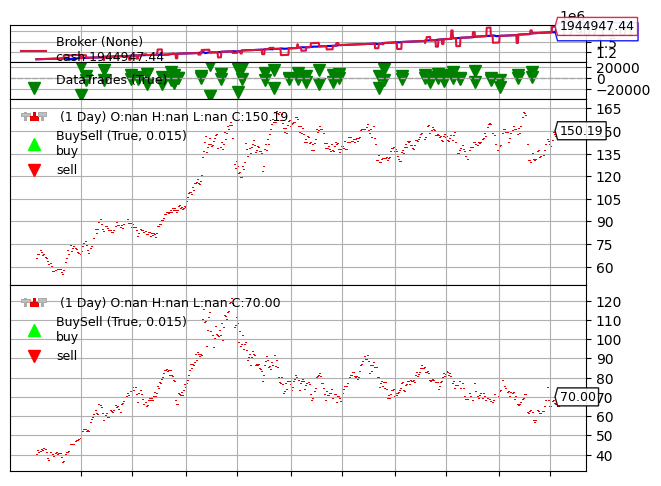

<Figure size 640x480 with 0 Axes>

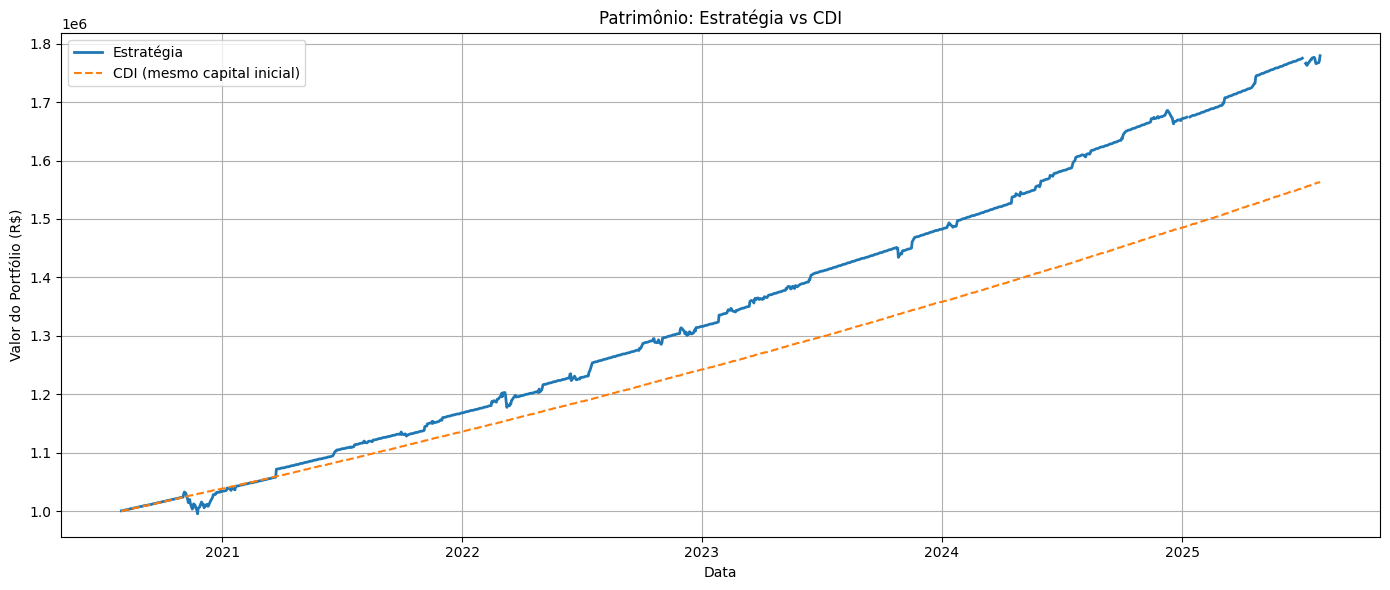

PERFORMANCE METRICS SUMMARY
Total Return: 44.73%
Average Return: 0.0356%
Compound Annual Growth Rate: 938.26%
Sharpe Ratio: 3.4009
SQN: N/A
Max Drawdown: 0.00%
Max Drawdown Duration: 1 periods
Max Drawdown Money: $0.00
Calmar Ratio: N/A
VWR: nan

TRADE ANALYSIS
Total Trades: 0

PORTFOLIO VALUE
Starting Portfolio Value: $1,000,000.00
Final Portfolio Value: $1,564,145.74
Total P&L: $564,145.74

Returns Series Length: 1257
Positions Tracked: 2
Transactions Recorded: 0


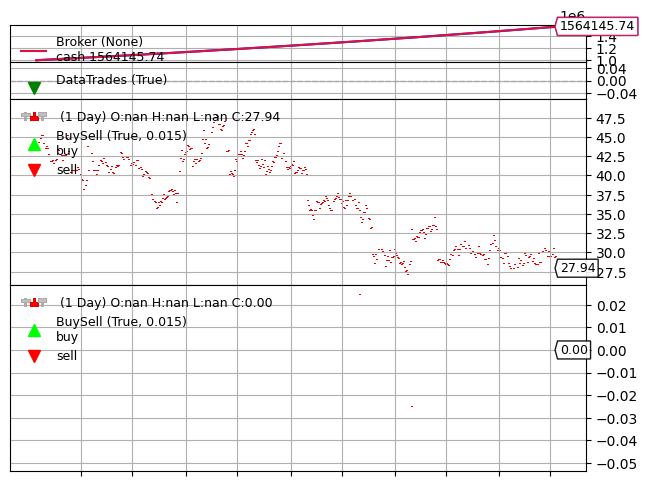

<Figure size 640x480 with 0 Axes>

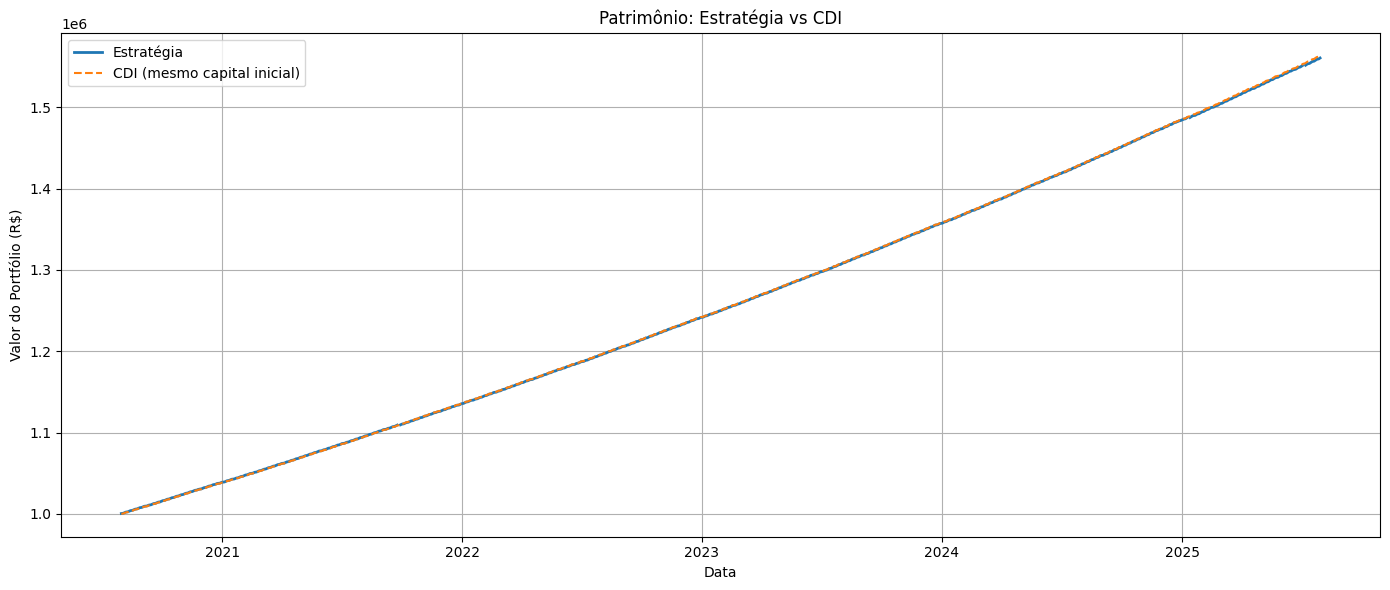

In [285]:
simulate("BHP", "TIO=F")
simulate("CVX", "CL=F")
simulate("HRL", "LET=F")